In [10]:
import pandas as pd
import geopandas as gd
import os 

In [11]:
df = pd.DataFrame()
for file in os.listdir("scr/CollectedData/"):
    if file.endswith(".csv"):
        _ = pd.read_csv(f"scr/CollectedData/{file}")
        df = pd.concat([df, _])

In [12]:
df

,Ticket #,Date Issue,Location,Type,Hour,Day
0,24P0900001,2024-01-03 11:42:00,PROUDFIT ST,Parking,11,Wednesday
1,24P0900002,2024-01-03 11:54:00,MAIN ST,Parking,11,Wednesday
2,24P0900003,2024-01-03 11:57:00,MAIN ST,Parking,11,Wednesday
3,24P0900004,2024-01-03 11:58:00,MAIN ST,Parking,11,Wednesday
4,24P0900005,2024-01-03 12:01:00,MAIN ST,Parking,12,Wednesday
...,...,...,...,...,...,...
1973,24P0401969,2024-08-17 13:29:00,MAIN ST,Meter,13,Saturday
1974,24P0401970,2024-08-17 13:32:00,FAIRCHILD ST,Meter,13,Saturday
1975,24P0401971,2024-08-17 13:35:00,FAIRCHILD ST,Meter,13,Saturday
1976,24P0401972,2024-08-17 13:41:00,MAIN ST,Meter,13,Saturday


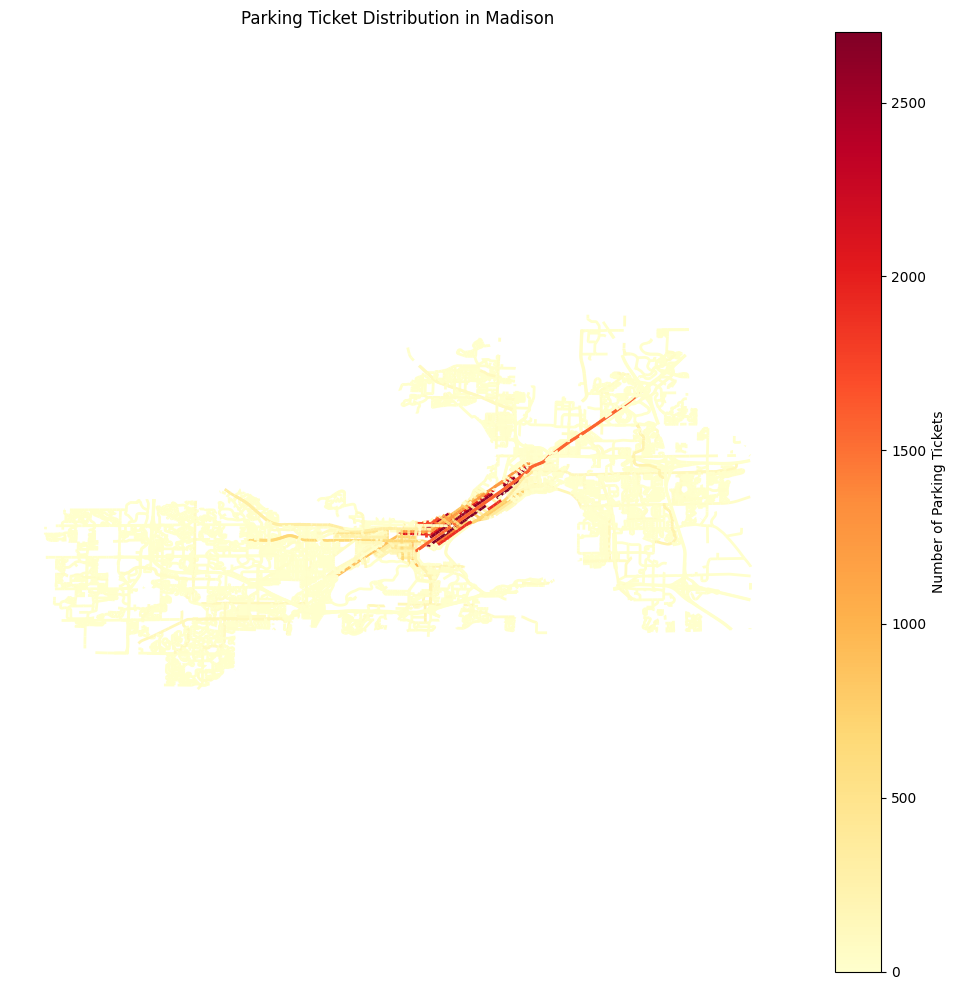

In [ ]:
import ast
import matplotlib.pyplot as plt
from shapely.geometry import LineString

streets_df = pd.read_csv("scr/CollectedData/Map/insideMad2.csv")

def create_linestring(coord_str):
    try:
        coords = ast.literal_eval(coord_str)
        return LineString(coords)
    except:
        return None


gdf = gd.GeoDataFrame(streets_df, geometry=streets_df['CoordList'].apply(create_linestring))
street_counts = df['Location'].value_counts()
gdf['ticket_count'] = gdf['fullStreetName'].str.upper().map(street_counts).fillna(0)

fig, ax = plt.subplots(figsize=(10, 10))

gdf.plot(column='ticket_count', 
         ax=ax,
         linewidth=2,
         legend=True,
         cmap='YlOrRd', 
         legend_kwds={'label': 'Number of Parking Tickets'})

ax.set_title('Parking Ticket Distribution in Madison')
ax.axis('equal')
plt.axis('off')

plt.tight_layout()
plt.show()

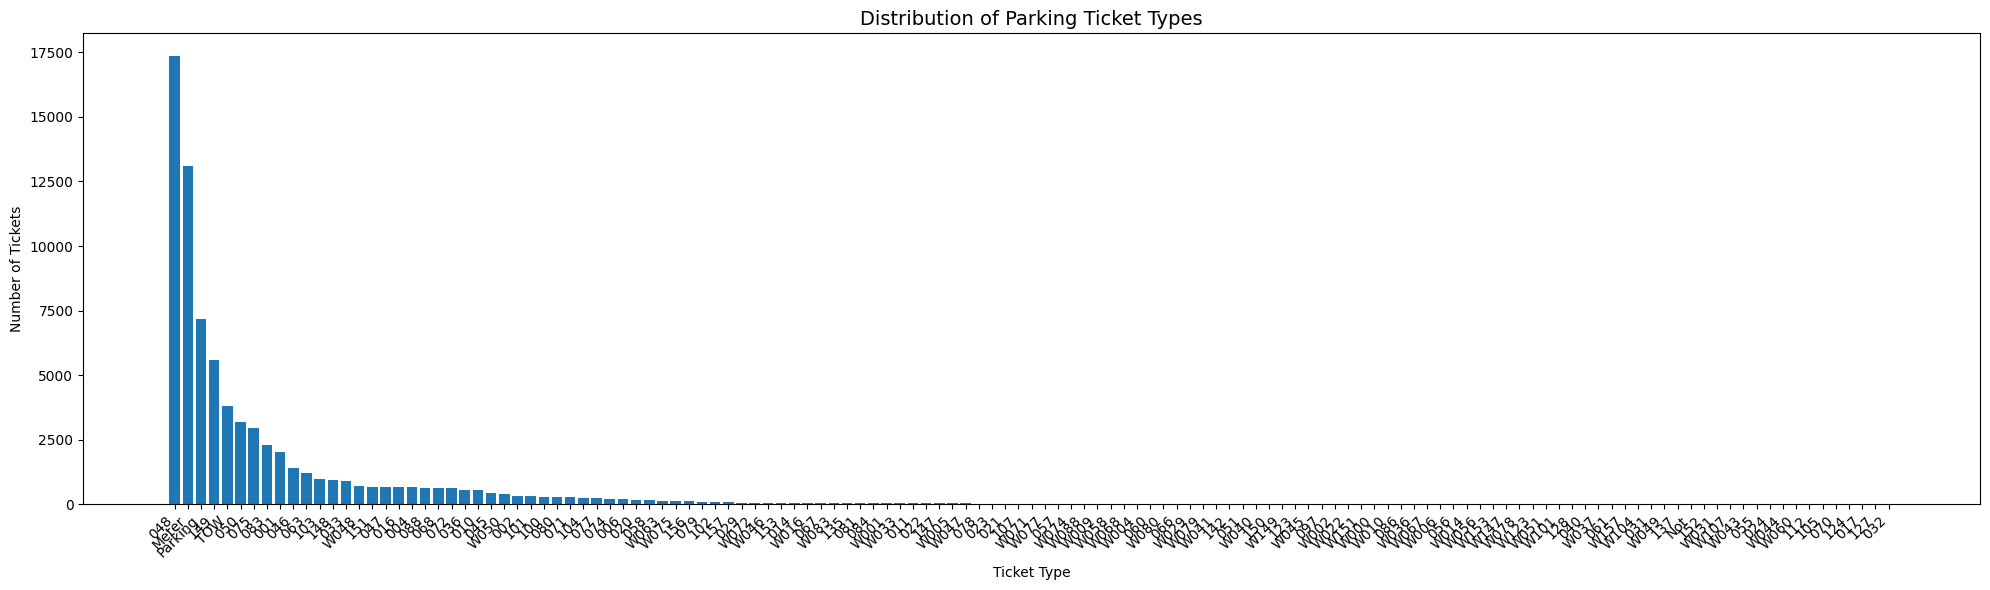


Ticket Type Counts:
Type
048        17368
Meter      13098
Parking     7166
149         5595
TOW         3794
           ...  
070            1
124            1
017            1
127            1
032            1
Name: count, Length: 131, dtype: int64


In [ ]:
plt.figure(figsize=(20, 6))
ticket_type_counts = df['Type'].value_counts()
plt.bar(range(len(ticket_type_counts)), ticket_type_counts.values)
plt.title('Distribution of Parking Ticket Types', fontsize=14)
plt.xlabel('Ticket Type')
plt.ylabel('Number of Tickets')
plt.xticks(range(len(ticket_type_counts)), ticket_type_counts.index, rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nTicket Type Counts:")
print(ticket_type_counts)